In [ ]:
!pip install ultralytics matplotlib seaborn

In [ ]:
!pip uninstall mediapipe -y

# Cтабильная версию 0.10.9 (работает с новым API)
!pip install mediapipe==0.10.9

Found existing installation: mediapipe 0.10.9
Uninstalling mediapipe-0.10.9:
  Successfully uninstalled mediapipe-0.10.9
  Using cached mediapipe-0.10.9-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.6 kB)
Using cached mediapipe-0.10.9-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.5 MB)


In [ ]:
import os
import sys
import time
import json
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from datetime import datetime
from scipy.interpolate import interp1d
from collections import deque
import cv2
import math

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

print("Библиотеки импортированы")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Библиотеки импортированы
PyTorch version: 2.10.0+cu128
CUDA available: True


In [ ]:
# Глобальные настройки для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
print("Семя установлено на 42")

Семя установлено на 42


In [ ]:
# Маппинг классов NTU RGB+D 60 (60 классов)
NTU_CLASSES = {
    0: "drink water",
    1: "eat meal/snack",
    2: "brushing teeth",
    3: "brushing hair",
    4: "drop",
    5: "pickup",
    6: "throw",
    7: "sitting down",
    8: "standing up (from sitting position)",
    9: "clapping",
    10: "reading",
    11: "writing",
    12: "tear up paper",
    13: "wear jacket",
    14: "take off jacket",
    15: "wear a shoe",
    16: "take off a shoe",
    17: "wear on glasses",
    18: "take off glasses",
    19: "put on a hat/cap",
    20: "take off a hat/cap",
    21: "cheer up",
    22: "hand waving",
    23: "kicking something",
    24: "reach into pocket",
    25: "hopping (one foot jumping)",
    26: "jump up",
    27: "make a phone call/answer phone",
    28: "playing with phone/tablet",
    29: "typing on a keyboard",
    30: "pointing to something with finger",
    31: "taking a selfie",
    32: "check time (from watch)",
    33: "rub two hands together",
    34: "nod head/bow",
    35: "shake head",
    36: "wipe face",
    37: "salute",
    38: "put the palms together",
    39: "cross hands in front (say stop)",
    40: "sneeze/cough",
    41: "staggering",
    42: "falling",
    43: "touch head (headache)",
    44: "touch chest (stomachache/heart pain)",
    45: "touch back (backache)",
    46: "touch neck (neckache)",
    47: "nausea or vomiting",
    48: "use a fan (with hand or paper)/feeling warm",
    49: "punching/slapping other person",
    50: "kicking other person",
    51: "pushing other person",
    52: "pat on back of other person",
    53: "point finger at the other person",
    54: "hugging other person",
    55: "giving something to other person",
    56: "touch other person's pocket",
    57: "handshaking",
    58: "walking towards each other",
    59: "walking apart from each other"
}

# Маппинг для групповых и индивидуальных действий
ACTION_MAPPING = {
    # Индивидуальные действия
    'sitting': ['sitting down', 'sit', 'sitting'],
    'walking': ['walking', 'walk'],
    'jumping': ['jumping', 'jump', 'hop', 'jump up'],
    'smoking': ['smoking', 'smoke'],

    # Групповые действия
    'fight': ['fighting', 'punching', 'kicking', 'fighting 2', 'punching/slapping other person', 'kicking other person'],
    'dance': ['dancing', 'dance'],
    'handshake': ['shaking hands', 'handshake', 'shake hands', 'handshaking'],
    'hug': ['hugging', 'hug', 'hugging other person'],
    'meeting': ['meeting', 'gathering'],
    'circle': ['forming circle', 'circle', 'make circle'],
    'tug_of_war': ['tug of war', 'pulling', 'rope pulling']
}

def get_action_name(action_id):
    """
    Преобразует числовой ID действия в норм название
    """
    if action_id in NTU_CLASSES:
        return NTU_CLASSES[action_id]
    return f"action_{action_id}"

def get_simplified_action_name(action_name):
    """
    Преобразует полное название действия в упрощённое (для отображения на видео)
    """
    action_lower = action_name.lower()

    # Проверка групповых действий
    for simplified, variants in ACTION_MAPPING.items():
        for variant in variants:
            if variant in action_lower:
                # Определяем тип действия
                if simplified in ['fight', 'dance', 'handshake', 'hug', 'meeting', 'circle', 'tug_of_war']:
                    return simplified, 'group'
                else:
                    return simplified, 'individual'

    # Если действие не найдено в маппинге, возвращаем оригинальное название
    return action_name, 'unknown'

# Функция для отображения на видео
def format_action_display(action_id, confidence):
    """
    Форматирует действие для отображения на видео
    Возвращает: (display_text, action_type)
    """
    # Получаем полное название
    full_name = get_action_name(action_id)

    # Получаем упрощённое название и тип
    simplified_name, action_type = get_simplified_action_name(full_name)

    # Форматируем для отображения
    if simplified_name != full_name:
        display_text = f"{simplified_name} ({action_type})"
    else:
        display_text = f"{full_name} ({action_type})"

    return display_text, action_type

In [ ]:
class Config:
    """ОПТИМИЗИРОВАННАЯ конфигурация системы"""
    SKELETON_DIR = 'data/nturgbd/skeletons/nturgb+d_skeletons'
    MODELS_DIR = 'models'
    RESULTS_DIR = 'results'
    LOGS_DIR = 'runs'

    NUM_JOINTS = 25
    NUM_COORDS = 3
    MAX_PEOPLE = 4
    TARGET_FRAMES = 150

    BATCH_SIZE = 32      # Увеличено с 16
    NUM_WORKERS = 4
    EPOCHS = 150
    LEARNING_RATE = 0.001  # Увеличено с 0.0005
    WEIGHT_DECAY = 0.0001
    MIXED_PRECISION = True

    EARLY_STOPPING_PATIENCE = 30

    # Улучшения для всех моделей
    AUGMENTATION_PROB = 0.3  # Уменьшено с 0.7
    USE_LABEL_SMOOTHING = True
    LABEL_SMOOTHING_VALUE = 0.1
    USE_COSINE_ANNEALING = True

    # Для предсказаний на видео
    PREDICTION_INTERVAL_FRAMES = 15
    SKIP_FRAMES = 2

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    EVALUATION_CLASSES = [
        'sitting down', 'standing up', 'walking', 'jumping',
        'fighting', 'dancing', 'shaking hands', 'hugging',
        'meeting', 'forming circle', 'tug of war'
    ]

config = Config()

for dir_path in [config.MODELS_DIR, config.RESULTS_DIR, config.LOGS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print(f"Конфигурация загружена. Устройство: {config.device}")
print(f"Параметры обучения: TARGET_FRAMES={config.TARGET_FRAMES}, BATCH_SIZE={config.BATCH_SIZE}, LR={config.LEARNING_RATE}")

Конфигурация загружена. Устройство: cuda
Параметры обучения: TARGET_FRAMES=150, BATCH_SIZE=32, LR=0.001


Классы действий

In [ ]:
INDIVIDUAL_ACTIONS = {
    'sitting': ['sitting down', 'sit', 'sitting'],
    'walking': ['walking', 'walk'],
    'jumping': ['jumping', 'jump', 'hop'],
    'smoking': ['smoking', 'smoke']
}

GROUP_ACTIONS = {
    'fight': ['fighting', 'punching', 'kicking', 'fighting 2'],
    'dance': ['dancing', 'dance'],
    'handshake': ['shaking hands', 'handshake', 'shake hands'],
    'hug': ['hugging', 'hug'],
    'meeting': ['meeting', 'gathering'],
    'circle': ['forming circle', 'circle', 'make circle'],
    'tug_of_war': ['tug of war', 'pulling', 'rope pulling']
}

REQUIRED_INDIVIDUAL = ['sitting', 'walking', 'jumping', 'smoking']
REQUIRED_GROUP = ['fight', 'dance', 'handshake', 'hug', 'meeting', 'circle', 'tug_of_war']

def map_ntu_to_required_actions(ntu_action_name):
    ntu_lower = ntu_action_name.lower()
    for req_action, ntu_list in INDIVIDUAL_ACTIONS.items():
        for ntu_name in ntu_list:
            if ntu_name in ntu_lower:
                return req_action, 'individual'
    for req_action, ntu_list in GROUP_ACTIONS.items():
        for ntu_name in ntu_list:
            if ntu_name in ntu_lower:
                return req_action, 'group'
    return None, None

def get_action_type(action_name):
    for req_action in REQUIRED_INDIVIDUAL:
        if req_action in action_name.lower():
            return 'individual'
    for req_action in REQUIRED_GROUP:
        if req_action in action_name.lower():
            return 'group'
    return 'unknown'

print("Классы действий настроены")
print(f"Индивидуальные: {REQUIRED_INDIVIDUAL}")
print(f"Групповые: {REQUIRED_GROUP}")

Классы действий настроены
Индивидуальные: ['sitting', 'walking', 'jumping', 'smoking']
Групповые: ['fight', 'dance', 'handshake', 'hug', 'meeting', 'circle', 'tug_of_war']


Обработка данных

In [ ]:
def parse_skeleton(filepath, max_bodies=4, target_frames=100):
    try:
        with open(filepath, 'r') as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]
        if len(lines) < 4:
            return None
        num_frames = int(lines[0])
        num_bodies = min(int(lines[1]), max_bodies)
        data = np.zeros((target_frames, max_bodies, 25, 3), dtype=np.float32)
        idx = 2
        actual_frames = min(num_frames, target_frames)
        for frame in range(actual_frames):
            for body in range(num_bodies):
                if idx >= len(lines):
                    break
                idx += 1
                try:
                    num_joints = int(lines[idx])
                    idx += 1
                except:
                    continue
                for j in range(min(num_joints, 25)):
                    if idx >= len(lines):
                        break
                    parts = lines[idx].split()
                    if len(parts) >= 3:
                        try:
                            x = float(parts[0])
                            y = float(parts[1])
                            z = float(parts[2])
                            if abs(x) < 100 and abs(y) < 100:
                                data[frame, body, j] = [x, y, z]
                        except:
                            pass
                    idx += 1
        return data
    except Exception as e:
        return None

def normalize_skeleton(data):
    """
    Улучшенная нормализация скелетных данных
    """
    if np.max(np.abs(data)) < 1e-6:
        return data

    T, M, V, C = data.shape
    normalized = np.zeros_like(data)

    for m in range(M):
        # Находим центр тела (таз - сустав 0)
        hip_center = data[:, m, 0, :].copy()

        # Центрируем относительно таза
        person_data = data[:, m, :, :] - hip_center[:, np.newaxis, :]

        # Нормализуем по размаху движений
        all_coords = person_data.reshape(-1, C)
        scale = np.percentile(np.abs(all_coords), 95)
        if scale > 1e-6:
            person_data = person_data / scale

        # Ограничиваем значения
        person_data = np.clip(person_data, -5, 5)
        normalized[:, m, :, :] = person_data

    return normalized

def interpolate_frames(data, target=100):
    T, M, V, C = data.shape
    if T == target:
        return data
    old_t = np.linspace(0, 1, T)
    new_t = np.linspace(0, 1, target)
    result = np.zeros((target, M, V, C), dtype=np.float32)
    for m in range(M):
        for v in range(V):
            for c in range(C):
                f = interp1d(old_t, data[:, m, v, c], kind='linear',
                            bounds_error=False,
                            fill_value=(data[0, m, v, c], data[-1, m, v, c]))
                result[:, m, v, c] = f(new_t)
    return result

def extract_label(filename):
    parts = filename.replace('.skeleton', '').split('A')
    if len(parts) >= 2:
        return int(parts[-1]) - 1
    return 0

print("Функции обработки данных загружены")

Функции обработки данных загружены


Dataset класс

In [ ]:
class SkeletonDataset(Dataset):
    def __init__(self, files, skeleton_dir, max_people=4, target_frames=100, augment=False):
        self.files = files
        self.skeleton_dir = skeleton_dir
        self.max_people = max_people
        self.target_frames = target_frames
        self.augment = augment
        self.augment_prob = 0.7  # Вероятность аугментации

        # сохраняем длину датасета
        self._len = len(files)

    def __len__(self):
        """Возвращает размер датасета"""
        return self._len

    def __getitem__(self, idx):
        filepath = os.path.join(self.skeleton_dir, self.files[idx])
        data = parse_skeleton(filepath, max_bodies=self.max_people, target_frames=self.target_frames)
        if data is None:
            data = np.zeros((self.target_frames, self.max_people, 25, 3), dtype=np.float32)
            label = 0
        else:
            data = normalize_skeleton(data)
            label = extract_label(self.files[idx])
        if self.augment and np.max(np.abs(data)) > 1e-6:
            data = self.augment_skeleton(data)
        tensor = torch.FloatTensor(data).permute(3, 0, 2, 1)
        return tensor, label

    def augment_skeleton(self, data):
        """
        Улучшенная аугментация для скелетных данных
        """
        T, M, V, C = data.shape
        augmented = data.copy()

        # 1. Небольшой временной сдвиг
        if random.random() < 0.3 and T > 50:
            shift = random.randint(-10, 10)
            augmented = np.roll(augmented, shift, axis=0)
            if shift > 0:
                augmented[:shift] = 0
            else:
                augmented[shift:] = 0

        # 2. Небольшое масштабирование
        if random.random() < 0.2:
            scale = random.uniform(0.85, 1.15)
            augmented = augmented * scale

        # 3. Небольшой шум
        if random.random() < 0.3:
            noise = np.random.normal(0, 0.005, augmented.shape).astype(np.float32)
            augmented = augmented + noise

        # 4. Зеркальное отражение
        if random.random() < 0.5:
            augmented[:, :, :, 0] = -augmented[:, :, :, 0]

        # 5. Небольшое вращение
        if random.random() < 0.2:
            angle = random.uniform(-15, 15) * np.pi / 180
            rot_matrix = np.array([[np.cos(angle), -np.sin(angle), 0],
                                  [np.sin(angle), np.cos(angle), 0],
                                  [0, 0, 1]])
            augmented_reshaped = augmented.reshape(-1, C)
            augmented_reshaped = augmented_reshaped @ rot_matrix.T
            augmented = augmented_reshaped.reshape(T, M, V, C)

        return augmented.astype(np.float32)

print("Dataset класс создан")

Dataset класс создан


Модель MLP

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, num_classes=60):
        super().__init__()
        self.num_classes = num_classes

        # Глобальное усреднение по пространству и времени
        self.global_avg = nn.AdaptiveAvgPool3d((1, 1, 1))

        # Уменьшаем размерность через свертку
        self.feature_extractor = nn.Sequential(
            nn.Conv3d(3, 32, kernel_size=(3, 3, 1), padding=(1, 1, 0)),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, Config.MAX_PEOPLE)),
        )

        # MLP классификатор
        self.classifier = nn.Sequential(
            nn.Linear(32 * Config.MAX_PEOPLE, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # x shape: (N, C, T, V, M)
        N, C, T, V, M = x.shape

        # Извлекаем признаки
        x = self.feature_extractor(x)  # (N, 32, 1, 1, M)
        x = x.view(N, -1)  # (N, 32 * M)

        # Классификация
        return self.classifier(x)

print("MLP модель создана")

MLP модель создана


Модель 3D CNN

In [ ]:
class Enhanced3DCNN(nn.Module):
    def __init__(self, num_classes=60, num_people=4):
        super().__init__()
        self.num_people = num_people
        self.conv1 = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.Conv3d(64, 64, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1))
        )
        self.conv2 = nn.Sequential(
            nn.Conv3d(64, 128, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.Conv3d(128, 128, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1))
        )
        self.conv3 = nn.Sequential(
            nn.Conv3d(128, 256, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),
            nn.Conv3d(256, 256, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True)
        )
        self.conv4 = nn.Sequential(
            nn.Conv3d(256, 512, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(512),
            nn.ReLU(inplace=True)
        )
        self.fusion = nn.Sequential(
            nn.Linear(512 * num_people, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        N, C, T, V, M = x.shape
        x = x.permute(0, 4, 1, 2, 3).reshape(N * M, C, T, V)
        x = x.unsqueeze(-1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = F.adaptive_avg_pool3d(x, (1, 1, 1))
        x = x.view(N, M, -1)
        x = x.reshape(N, -1)
        return self.fusion(x)

print("3D CNN модель создана")

3D CNN модель создана


Модель ST-GCN

In [ ]:
class GraphConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, num_joints=25):
        super().__init__()
        self.adj = nn.Parameter(torch.ones(num_joints, num_joints) / num_joints)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        N, C, T, V = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(N * T, V, C)
        adj_norm = F.softmax(self.adj, dim=1)
        x = torch.matmul(adj_norm, x)
        x = x.view(N, T, V, C).permute(0, 3, 1, 2).contiguous()
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

class TemporalConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=9, stride=1):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(in_channels, out_channels,
                             kernel_size=(kernel_size, 1),
                             padding=(padding, 0), stride=(stride, 1))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_joints=25, stride=1):
        super().__init__()
        self.gcn = GraphConvolution(in_channels, out_channels, num_joints)
        self.tcn = TemporalConvolution(out_channels, out_channels, kernel_size=9, stride=stride)
        self.residual = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        res = self.residual(x)
        x = self.gcn(x)
        x = self.tcn(x)
        return F.relu(x + res)

class STGCN(nn.Module):
    def __init__(self, num_classes=60, num_joints=25, num_people=4, in_channels=3):
        super().__init__()
        self.num_people = num_people
        self.conv_init = nn.Conv2d(in_channels, 64, kernel_size=1)
        self.bn_init = nn.BatchNorm2d(64)
        self.stgcn_blocks = nn.ModuleList([
            STGCNBlock(64, 64, num_joints, stride=1),
            STGCNBlock(64, 64, num_joints, stride=1),
            STGCNBlock(64, 64, num_joints, stride=1),
            STGCNBlock(64, 128, num_joints, stride=2),
            STGCNBlock(128, 128, num_joints, stride=1),
            STGCNBlock(128, 128, num_joints, stride=1),
            STGCNBlock(128, 256, num_joints, stride=2),
            STGCNBlock(256, 256, num_joints, stride=1),
            STGCNBlock(256, 256, num_joints, stride=1)
        ])
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fusion = nn.Sequential(
            nn.Linear(256 * num_people, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        N, C, T, V, M = x.shape
        all_features = []
        for m in range(M):
            person_x = x[:, :, :, :, m]
            person_x = self.conv_init(person_x)
            person_x = self.bn_init(person_x)
            person_x = F.relu(person_x)
            for block in self.stgcn_blocks:
                person_x = block(person_x)
            person_x = self.global_pool(person_x)
            person_x = person_x.view(N, -1)
            all_features.append(person_x)
        x = torch.cat(all_features, dim=1)
        return self.fusion(x)

print("ST-GCN модель создана")

ST-GCN модель создана


Модель Transformer

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]

class SkeletonTransformer(nn.Module):
    def __init__(self, num_classes=60, num_joints=25, num_people=4,
                 d_model=256, nhead=8, num_layers=4, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.num_people = num_people
        self.d_model = d_model

        # Уменьшаем размерность входных данных
        input_dim = 3 * num_joints
        self.input_proj = nn.Linear(input_dim, d_model)

        # Позиционное кодирование
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Linear(d_model * num_people, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        N, C, T, V, M = x.shape

        # Преобразуем в (N, T, M, C*V)
        x = x.permute(0, 2, 4, 1, 3).contiguous()
        x = x.view(N, T, M, -1)

        all_features = []
        for m in range(M):
            person_x = x[:, :, m, :]  # (N, T, input_dim)
            person_x = self.input_proj(person_x)  # (N, T, d_model)
            person_x = self.pos_encoder(person_x)  # (N, T, d_model)
            person_x = self.transformer(person_x)  # (N, T, d_model)

            # Глобальное усреднение по времени
            person_x = person_x.mean(dim=1)  # (N, d_model)
            all_features.append(person_x)

        # Объединяем признаки всех людей
        x = torch.cat(all_features, dim=1)  # (N, d_model * M)

        return self.classifier(x)

print("Transformer модель создана")

Transformer модель создана


Словарь моделей

In [ ]:
MODELS = {
    'mlp': {
        'class': SimpleMLP,
        'description': 'Простая полносвязная сеть (MLP) - быстрый baseline',
        'params': {'num_classes': 60},
        'features': ['простая', 'быстрая', 'низкая точность']
    },
    '3dcnn': {
        'class': Enhanced3DCNN,
        'description': '3D сверточная сеть - учитывает пространственно-временную структуру',
        'params': {'num_classes': 60, 'num_people': Config.MAX_PEOPLE},
        'features': ['пространственно-временные признаки', 'средняя скорость', 'хорошая точность']
    },
    'stgcn': {
        'class': STGCN,
        'description': 'Пространственно-временная графовая сеть (ST-GCN)',
        'params': {'num_classes': 60, 'num_joints': 25, 'num_people': Config.MAX_PEOPLE, 'in_channels': 3},
        'features': ['графовая структура', 'эффективность', 'высокая точность']
    },
    'transformer': {
        'class': SkeletonTransformer,
        'description': 'Трансформер для скелетных последовательностей',
        'params': {'num_classes': 60, 'num_joints': 25, 'num_people': Config.MAX_PEOPLE,
                   'd_model': 256, 'nhead': 8, 'num_layers': 4, 'dim_feedforward': 512},
        'features': ['долгосрочные зависимости', 'гибкость', 'высокая точность']
    }
}

print("Словарь моделей настроен")
for name, info in MODELS.items():
    print(f"  {name}: {info['description']}")

Словарь моделей настроен
  mlp: Простая полносвязная сеть (MLP) - быстрый baseline
  3dcnn: 3D сверточная сеть - учитывает пространственно-временную структуру
  stgcn: Пространственно-временная графовая сеть (ST-GCN)
  transformer: Трансформер для скелетных последовательностей


Функция обучения

In [ ]:
def train_model(model_name='3dcnn', num_epochs=None):
    config = Config()
    skeleton_dir = config.SKELETON_DIR

    if not os.path.exists(skeleton_dir):
        raise FileNotFoundError(f"Не найдена директория: {skeleton_dir}")
    if num_epochs is None:
        num_epochs = config.EPOCHS

    print(f"\n{'='*70}")
    print(f"ОБУЧЕНИЕ МОДЕЛИ: {model_name.upper()}")
    print(f"{'='*70}")

    all_files = [f for f in os.listdir(skeleton_dir) if f.endswith('.skeleton')]
    all_labels = [extract_label(f) for f in all_files]
    num_classes = max(all_labels) + 1

    # Стратифицированное разделение
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    train_idx, val_idx = next(sss.split(all_files, all_labels))
    train_files = [all_files[i] for i in train_idx]
    val_files = [all_files[i] for i in val_idx]

    print(f"  - Train samples: {len(train_files)}")
    print(f"  - Val samples: {len(val_files)}")
    print(f"  - Classes: {num_classes}")

    # Датасеты
    train_dataset = SkeletonDataset(train_files, skeleton_dir, max_people=config.MAX_PEOPLE,
                                    target_frames=config.TARGET_FRAMES, augment=True)
    val_dataset = SkeletonDataset(val_files, skeleton_dir, max_people=config.MAX_PEOPLE,
                                  target_frames=config.TARGET_FRAMES, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
                              num_workers=config.NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                            num_workers=config.NUM_WORKERS, pin_memory=True)

    model_params = MODELS[model_name]['params'].copy()
    model = MODELS[model_name]['class'](**model_params).to(config.device)

    # Разные learning rates для разных моделей
    if model_name == 'mlp':
        lr = 0.001
    elif model_name == 'transformer':
        lr = 0.0005
    else:
        lr = config.LEARNING_RATE

    print(f"  - Learning Rate: {lr}")
    print(f"  - Batch Size: {config.BATCH_SIZE}")
    print(f"  - Target Frames: {config.TARGET_FRAMES}")
    print(f"  - Weight Decay: {config.WEIGHT_DECAY}")
    print(f"  - Label Smoothing: {config.LABEL_SMOOTHING_VALUE if config.USE_LABEL_SMOOTHING else 'Off'}")

    # Label smoothing
    if config.USE_LABEL_SMOOTHING:
        criterion = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTHING_VALUE)
    else:
        criterion = nn.CrossEntropyLoss()

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                  weight_decay=config.WEIGHT_DECAY)

    # Scheduler
    if config.USE_COSINE_ANNEALING:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

    scaler = torch.amp.GradScaler('cuda') if config.MIXED_PRECISION else None

    run_name = f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    writer = SummaryWriter(log_dir=os.path.join(config.LOGS_DIR, run_name))

    print(f"  - Model params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"  - Device: {config.device}")

    best_acc = 0
    patience = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for data, labels in train_loader:
            data, labels = data.to(config.device), labels.to(config.device)
            optimizer.zero_grad()

            if config.MIXED_PRECISION and scaler is not None:
                with torch.amp.autocast('cuda'):
                    outputs = model(data)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(data)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)

        train_acc = 100. * train_correct / train_total

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, labels in val_loader:
                data, labels = data.to(config.device), labels.to(config.device)
                if config.MIXED_PRECISION:
                    with torch.amp.autocast('cuda'):
                        outputs = model(data)
                else:
                    outputs = model(data)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        val_acc = 100. * val_correct / val_total

        # Update scheduler
        if config.USE_COSINE_ANNEALING:
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]
        else:
            scheduler.step(val_acc)
            current_lr = optimizer.param_groups[0]['lr']

        # Сохраняем историю
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        epoch_time = time.time() - epoch_start

        # Сохраняем лучшую модель
        if val_acc > best_acc:
            best_acc = val_acc
            patience = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'accuracy': val_acc,
                'num_classes': num_classes,
                'model_name': model_name,
                'history': history,
                'config': {
                    'target_frames': config.TARGET_FRAMES,
                    'learning_rate': lr,
                    'batch_size': config.BATCH_SIZE,
                    'label_smoothing': config.LABEL_SMOOTHING_VALUE if config.USE_LABEL_SMOOTHING else 0
                }
            }, os.path.join(config.MODELS_DIR, f'{model_name}_best.pth'))
        else:
            patience += 1

        # Logging
        writer.add_scalar('Loss/train', train_loss/len(train_loader), epoch)
        writer.add_scalar('Loss/val', val_loss/len(val_loader), epoch)
        writer.add_scalar('Accuracy/train', train_acc, epoch)
        writer.add_scalar('Accuracy/val', val_acc, epoch)
        writer.add_scalar('Learning_rate', current_lr, epoch)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{num_epochs} | "
                  f"Loss={train_loss/len(train_loader):.4f} | "
                  f"Train Acc={train_acc:.2f}% | "
                  f"Val Acc={val_acc:.2f}% | "
                  f"LR={current_lr:.6f} | "
                  f"Time={epoch_time:.1f}s")

        if patience >= config.EARLY_STOPPING_PATIENCE:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break

    writer.close()
    print(f"\nОбучение завершено! Лучшая точность: {best_acc:.2f}%")
    print(f"Модель сохранена: {config.MODELS_DIR}/{model_name}_best.pth")

    plot_training_history(history, model_name,
                     os.path.join(config.RESULTS_DIR, f'{model_name}_training.png'))

    return model, history, best_acc

print("Функция обучения создана")

Функция обучения создана


Функция оценки

In [ ]:
def evaluate_model(model_path, test_files=None):
    config = Config()
    skeleton_dir = config.SKELETON_DIR

    print(f"\n{'='*70}")
    print("ОЦЕНКА МОДЕЛИ")
    print(f"{'='*70}")

    checkpoint = torch.load(model_path, map_location=config.device, weights_only=False)
    model_name = checkpoint.get('model_name', 'unknown')
    num_classes = checkpoint.get('num_classes', 60)

    model = MODELS[model_name]['class'](**MODELS[model_name]['params'].copy()).to(config.device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Модель: {model_name}")
    print(f"Лучшая точность при обучении: {checkpoint.get('accuracy', 0):.2f}%")

    # Показываем конфиг обучения
    if 'config' in checkpoint:
        cfg = checkpoint['config']
        print(f"Параметры обучения:")
        print(f"  - Target frames: {cfg.get('target_frames', 'N/A')}")
        print(f"  - Learning rate: {cfg.get('learning_rate', 'N/A')}")
        print(f"  - Batch size: {cfg.get('batch_size', 'N/A')}")

    if test_files is None:
        all_files = [f for f in os.listdir(skeleton_dir) if f.endswith('.skeleton')]
        _, test_files = train_test_split(all_files, test_size=0.1, random_state=42)

    test_dataset = SkeletonDataset(test_files, skeleton_dir, max_people=config.MAX_PEOPLE,
                                   target_frames=config.TARGET_FRAMES, augment=False)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                             num_workers=config.NUM_WORKERS, pin_memory=True)

    all_preds = []
    all_labels = []
    all_probs = []  # Сохраняем вероятности для анализа
    inference_times = []
    predictions_details = []

    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(config.device)
            start_time = time.time()
            outputs = model(data)
            probs = torch.softmax(outputs, dim=1)
            inference_times.append(time.time() - start_time)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

            for i, (pred, true, prob) in enumerate(zip(predicted.cpu().numpy(), labels.numpy(), probs.cpu().numpy())):
                predictions_details.append({
                    'predicted_id': pred,
                    'predicted_name': get_action_name(pred),
                    'true_id': true,
                    'true_name': get_action_name(true),
                    'confidence': prob[pred] * 100
                })

    accuracy = accuracy_score(all_labels, all_preds) * 100
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0) * 100

    avg_inference_time = np.mean(inference_times)
    fps = 1.0 / avg_inference_time if avg_inference_time > 0 else 0

    print(f"\nМЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:")
    print(f"   Accuracy:  {accuracy:.2f}%")
    print(f"   Precision: {precision:.2f}%")
    print(f"   Recall:    {recall:.2f}%")
    print(f"   F1-score:  {f1:.2f}%")
    print(f"   FPS:       {fps:.2f}")

    # Анализ ошибок
    errors = [d for d in predictions_details if d['predicted_id'] != d['true_id']]
    print(f"\nАНАЛИЗ ОШИБОК:")
    print(f"   Всего ошибок: {len(errors)}/{len(predictions_details)} ({len(errors)/len(predictions_details)*100:.1f}%)")

    if errors:
        print(f"\n   Примеры ошибок (первые 10):")
        for i, err in enumerate(errors[:10]):
            print(f"   {i+1}. True: {err['true_name']:40s} → Pred: {err['predicted_name']:40s} (conf: {err['confidence']:.1f}%)")

    plot_confusion_matrix(all_labels, all_preds,
                     save_path=os.path.join(config.RESULTS_DIR, f'{model_name}_cm.png'))

    return {
        'model_name': model_name,
        'description': MODELS[model_name]['description'],
        'features': MODELS[model_name]['features'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'fps': fps,
        'predictions': all_preds,
        'labels': all_labels,
        'predictions_details': predictions_details,
        'errors': errors
    }

print("Функция оценки создана")

Функция оценки создана


Сравнение моделей

In [ ]:
def compare_all_models():
    config = Config()

    print(f"Сравнение всех моделей")

    results = {}
    model_list = ['mlp', '3dcnn', 'stgcn', 'transformer']

    for model_name in model_list:
        model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
        if not os.path.exists(model_path):
            print(f"Модель {model_name} не найдена. Пропускаем.")
            continue

        print(f"Оценка модели: {model_name.upper()}")
        eval_result = evaluate_model(model_path)
        results[model_name] = eval_result

    if len(results) >= 1:
        print(f"Сводное сравнение всех моделей")

        comparison_data = {}
        for model_name, res in results.items():
            comparison_data[model_name.upper()] = {
                'Accuracy (%)': res['accuracy'],
                'Precision (%)': res['precision'],
                'Recall (%)': res['recall'],
                'F1-score (%)': res['f1_score'],
                'FPS': res['fps']
            }

        comparison = pd.DataFrame(comparison_data).T
        print(comparison.round(2))

        if results:
            best_model = max(results.keys(), key=lambda x: results[x]['accuracy'])
            print(f"Лучшая модель по точности: {best_model.upper()}")
            print(f"   Accuracy: {results[best_model]['accuracy']:.2f}%")

            fastest_model = max(results.keys(), key=lambda x: results[x]['fps'])
            print(f"Самая быстрая модель: {fastest_model.upper()}")
            print(f"   FPS: {results[fastest_model]['fps']:.2f}")

        comparison.to_csv(os.path.join(config.RESULTS_DIR, 'models_comparison.csv'))
        print(f"Сравнение сохранено: {config.RESULTS_DIR}/models_comparison.csv")
        plot_model_comparison(results,
                     save_path=os.path.join(config.RESULTS_DIR, 'models_comparison.png'))

    return results

print("Функция сравнения создана")

Функция сравнения создана


In [ ]:
def retrain_all_models_optimized(force_retrain=False):
    """
    Переобучение всех моделей с оптимизированными параметрами

    Args:
        force_retrain: Если True, переобучает все модели, даже если они существуют.
                      Если False, проверяет наличие и спрашивает перед переобучением.
    """
    config = Config()

    print("\n" + "="*70)
    print("ПЕРЕОБУЧЕНИЕ ВСЕХ МОДЕЛЕЙ С ОПТИМАЛЬНЫМИ ПАРАМЕТРАМИ")
    print("="*70)
    print(f"\nПАРАМЕТРЫ ОБУЧЕНИЯ:")
    print(f"  - Target frames: {config.TARGET_FRAMES}")
    print(f"  - Batch size: {config.BATCH_SIZE}")
    print(f"  - Learning rate: {config.LEARNING_RATE}")
    print(f"  - Weight decay: {config.WEIGHT_DECAY}")
    print(f"  - Label smoothing: {config.LABEL_SMOOTHING_VALUE}")
    print(f"  - Cosine annealing: {config.USE_COSINE_ANNEALING}")
    print(f"  - Epochs: {config.EPOCHS}")

    results = {}
    models_to_train = []

    # Проверяем существующие модели
    print("\nПРОВЕРКА СУЩЕСТВУЮЩИХ МОДЕЛЕЙ:")
    for model_name in ['3dcnn', 'mlp', 'stgcn', 'transformer']:
        model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
        if os.path.exists(model_path):
            # Загружаем информацию о существующей модели
            try:
                checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
                existing_acc = checkpoint.get('accuracy', 0)
                existing_epochs = checkpoint.get('epoch', 0)
                print(f"{model_name.upper()}: существует (точность: {existing_acc:.2f}%, эпох: {existing_epochs})")
            except:
                print(f"{model_name.upper()}: существует (не удалось прочитать метрики)")
        else:
            print(f" {model_name.upper()}: не существует")
            models_to_train.append(model_name)

    # Если не принудительное переобучение, спрашиваем
    if not force_retrain and models_to_train:
        print(f"\nМодели для обучения: {models_to_train}")
        proceed = input("Продолжить обучение только отсутствующих моделей? (y/n): ").strip().lower()
        if proceed != 'y':
            print("Операция отменена")
            return results

    # Если нужно переобучить все, спрашиваем подтверждение
    if not force_retrain and not models_to_train:
        print("\nВСЕ МОДЕЛИ УЖЕ ОБУЧЕНЫ!")
        retrain_all = input("Переобучить все модели? (y/n): ").strip().lower()
        if retrain_all == 'y':
            models_to_train = ['3dcnn', 'mlp', 'stgcn', 'transformer']
            print("Будут переобучены все модели")
        else:
            print("Операция отменена")
            return results

    # Если force_retrain=True, обучаем все
    if force_retrain:
        models_to_train = ['3dcnn', 'mlp', 'stgcn', 'transformer']
        print("\nПринудительное переобучение всех моделей")

    # Обучаем выбранные модели
    for model_name in models_to_train:
        print(f"\n{'#'*70}")
        print(f"# ОБУЧЕНИЕ: {model_name.upper()}")
        print(f"{'#'*70}")

        model, history, best_acc = train_model(model_name, num_epochs=config.EPOCHS)
        results[model_name] = best_acc

        # Оценка после обучения
        model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
        if os.path.exists(model_path):
            eval_result = evaluate_model(model_path)
            print(f"{model_name.upper()} обучена: {best_acc:.2f}%")
        else:
            print(f"Ошибка при обучении {model_name.upper()}")

    # Если были обучены новые модели, проводим сравнение
    if results:
        print("\n" + "="*70)
        print("ИТОГОВОЕ СРАВНЕНИЕ ПОСЛЕ ОПТИМИЗАЦИИ")
        print("="*70)
        for name, acc in results.items():
            print(f"  {name.upper()}: {acc:.2f}%")

        # Находим лучшую модель
        best_model = max(results, key=results.get)
        print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model.upper()} с точностью {results[best_model]:.2f}%")

        compare_all_models()
    else:
        print("\nНовые модели не были обучены. Для сравнения используйте режим 3.")

    return results

MediaPipe детектор

In [ ]:
class MediaPipeDetector:
    """Детектор скелетов"""

    def __init__(self, max_people=4):
        self.max_people = max_people

        try:
            import mediapipe as mp
            print(f"MediaPipe версия: {mp.__version__}")

            # Для версий 0.10.x
            self.mp_pose = mp.solutions.pose
            self.pose = self.mp_pose.Pose(
                static_image_mode=False,
                model_complexity=1,
                min_detection_confidence=0.5,
                min_tracking_confidence=0.5
            )
            self.mp_drawing = mp.solutions.drawing_utils
            self.use_old_api = True  # Используем старый API, который работает

        except Exception as e:
            print(f"Ошибка инициализации MediaPipe: {e}")
            print("Попытка альтернативной инициализации...")
            try:
                import mediapipe as mp
                # Альтернативный способ
                self.mp_pose = mp.solutions.pose
                self.pose = self.mp_pose.Pose(
                    static_image_mode=False,
                    model_complexity=1,
                    min_detection_confidence=0.5,
                    min_tracking_confidence=0.5
                )
                self.mp_drawing = mp.solutions.drawing_utils
                self.use_old_api = True
            except:
                self.pose = None
                self.mp_drawing = None
                self.use_old_api = False
                print("MediaPipe не инициализирован")

    def extract_all_persons(self, frame):
        """Извлечение скелетов из кадра"""
        if self.pose is None:
            return np.zeros((self.max_people, 25, 3), dtype=np.float32), None

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        skeletons = []
        results_obj = None

        try:
            results = self.pose.process(rgb_frame)
            results_obj = results

            if results.pose_world_landmarks:
                person_landmarks = results.pose_world_landmarks.landmark
                coords = np.array([[lm.x, lm.y, lm.z] for lm in person_landmarks])

                skeleton = np.zeros((25, 3), dtype=np.float32)
                skeleton[:min(len(coords), 25)] = coords[:25]
                skeletons.append(skeleton)

        except Exception as e:
            pass

        # Дополняем до max_people
        while len(skeletons) < self.max_people:
            skeletons.append(np.zeros((25, 3), dtype=np.float32))

        if len(skeletons) > self.max_people:
            skeletons = skeletons[:self.max_people]

        return np.array(skeletons, dtype=np.float32), results_obj

    def draw_skeleton(self, frame, results):
        """Отрисовка скелета"""
        if results and self.mp_drawing and hasattr(results, 'pose_landmarks') and results.pose_landmarks:
            try:
                self.mp_drawing.draw_landmarks(
                    frame, results.pose_landmarks, self.mp_pose.POSE_CONNECTIONS,
                    self.mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=2),
                    self.mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2)
                )
            except:
                pass
        return frame

    def release(self):
        if self.pose:
            self.pose.close()

детектор с поддержкой нескольких людей

In [ ]:
class MultiPersonDetector:
    """
    Детектор скелетов для нескольких людей с использованием YOLOv8-Pose
    """

    def __init__(self, max_people=4):
        self.max_people = max_people
        self.use_yolo = False
        self.use_mediapipe = False
        self.yolo_model = None

        # Пробуем загрузить YOLOv8
        try:
            from ultralytics import YOLO
            print("Загрузка YOLOv8-pose модели...")
            # Используем n-модель для скорости, p-модель для точности
            self.yolo_model = YOLO('yolov8n-pose.pt')
            self.use_yolo = True
            print("YOLOv8-pose загружена")
        except Exception as e:
            print(f"YOLOv8 недоступен: {e}")

            # Fallback на MediaPipe
            try:
                import mediapipe as mp
                print("Используем MediaPipe (только 1 человек)")
                self.mp_pose = mp.solutions.pose
                self.pose = self.mp_pose.Pose(
                    static_image_mode=False,
                    model_complexity=1,
                    min_detection_confidence=0.5,
                    min_tracking_confidence=0.5
                )
                self.mp_drawing = mp.solutions.drawing_utils
                self.use_mediapipe = True
            except Exception as e2:
                print(f"MediaPipe также недоступен: {e2}")
                self.pose = None
                print("Детектор не инициализирован, будут использоваться нулевые скелеты")

    def extract_all_persons(self, frame):
        """
        Извлечение скелетов для всех людей в кадре
        """
        if self.use_yolo:
            return self._extract_with_yolo(frame)
        elif self.use_mediapipe:
            return self._extract_with_mediapipe(frame)
        else:
            return np.zeros((self.max_people, 25, 3), dtype=np.float32), None

    def _extract_with_yolo(self, frame):
        """
        Извлечение скелетов через YOLOv8-pose
        """
        # Уменьшаем разрешение для ускорения
        h, w = frame.shape[:2]
        if w > 640:
            scale = 640 / w
            new_w = 640
            new_h = int(h * scale)
            frame_small = cv2.resize(frame, (new_w, new_h))
        else:
            frame_small = frame

        results = self.yolo_model(frame_small, verbose=False)
        skeletons = []
        results_obj = results[0]

        # Масштабирование координат обратно
        scale_x = frame.shape[1] / frame_small.shape[1]
        scale_y = frame.shape[0] / frame_small.shape[0]

        if results_obj.keypoints is not None:
            keypoints = results_obj.keypoints.data.cpu().numpy()

            for person_keypoints in keypoints[:self.max_people]:
                skeleton = np.zeros((25, 3), dtype=np.float32)

                # Маппинг YOLOv8-pose (17 точек) -> NTU (25 точек)
                # 0: nose -> центр
                # 1: left_eye, 2: right_eye -> пропускаем
                # 3: left_ear, 4: right_ear -> пропускаем
                # 5: left_shoulder, 6: right_shoulder
                # 7: left_elbow, 8: right_elbow
                # 9: left_wrist, 10: right_wrist
                # 11: left_hip, 12: right_hip
                # 13: left_knee, 14: right_knee
                # 15: left_ankle, 16: right_ankle

                mapping = {
                    0: 0,   # nose -> центр тела (условно)
                    5: 1,   # left_shoulder -> левое плечо
                    6: 2,   # right_shoulder -> правое плечо
                    7: 3,   # left_elbow -> левый локоть
                    8: 4,   # right_elbow -> правый локоть
                    9: 5,   # left_wrist -> левое запястье
                    10: 6,  # right_wrist -> правое запястье
                    11: 7,  # left_hip -> левое бедро
                    12: 8,  # right_hip -> правое бедро
                    13: 9,  # left_knee -> левое колено
                    14: 10, # right_knee -> правое колено
                    15: 11, # left_ankle -> левая лодыжка
                    16: 12, # right_ankle -> правая лодыжка
                }

                for yolo_idx, ntu_idx in mapping.items():
                    if yolo_idx < len(person_keypoints):
                        x, y, conf = person_keypoints[yolo_idx]
                        if conf > 0.3:
                            # Масштабируем координаты обратно
                            skeleton[ntu_idx] = [x * scale_x, y * scale_y, 0]

                skeletons.append(skeleton)

        # Дополняем до max_people
        while len(skeletons) < self.max_people:
            skeletons.append(np.zeros((25, 3), dtype=np.float32))

        if len(skeletons) > self.max_people:
            skeletons = skeletons[:self.max_people]

        return np.array(skeletons, dtype=np.float32), results_obj

    def _extract_with_mediapipe(self, frame):
        """
        Fallback на MediaPipe (только 1 человек)
        """
        if self.pose is None:
            return np.zeros((self.max_people, 25, 3), dtype=np.float32), None

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        skeletons = []
        results_obj = None

        try:
            results = self.pose.process(rgb_frame)
            results_obj = results

            if results.pose_world_landmarks:
                person_landmarks = results.pose_world_landmarks.landmark
                coords = np.array([[lm.x, lm.y, lm.z] for lm in person_landmarks])

                skeleton = np.zeros((25, 3), dtype=np.float32)
                skeleton[:min(len(coords), 25)] = coords[:25]
                skeletons.append(skeleton)

        except Exception as e:
            pass

        # Дополняем до max_people
        while len(skeletons) < self.max_people:
            skeletons.append(np.zeros((25, 3), dtype=np.float32))

        return np.array(skeletons, dtype=np.float32), results_obj

    def draw_skeleton(self, frame, results):
        """
        Отрисовка скелетов для всех людей
        """
        if self.use_yolo and results is not None:
            try:
                # Рисуем скелеты через YOLO
                annotated = results.plot()
                return annotated
            except:
                pass
        elif self.use_mediapipe and results and hasattr(results, 'pose_landmarks') and results.pose_landmarks:
            try:
                self.mp_drawing.draw_landmarks(
                    frame, results.pose_landmarks, self.mp_pose.POSE_CONNECTIONS,
                    self.mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=2),
                    self.mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2)
                )
            except:
                pass
        return frame

    def release(self):
        if hasattr(self, 'pose') and self.pose:
            self.pose.close()

Демонстрация на видео

In [ ]:
def demo_video(model_path, video_path, output_path=None, skip_frames=1, max_people=4):
    """
    Демонстрация распознавания на видео с поддержкой нескольких людей
    """
    config = Config()

    if not os.path.exists(video_path):
        print(f"Видео не найдено: {video_path}")
        return None

    print(f"\n{'='*70}")
    print("ДЕМОНСТРАЦИЯ НА ВИДЕО")
    print(f"{'='*70}")

    # Загрузка модели
    checkpoint = torch.load(model_path, map_location=config.device, weights_only=False)
    model_name = checkpoint.get('model_name', '3dcnn')

    model = MODELS[model_name]['class'](**MODELS[model_name]['params'].copy()).to(config.device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Используем улучшенный детектор
    detector = MultiPersonDetector(max_people=max_people)

    print(f"Модель: {model_name}")
    print(f"Детектор: {'YOLOv8-pose' if detector.use_yolo else 'MediaPipe'}")
    print(f"Максимум людей в кадре: {max_people}")

    # Открытие видео
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Не удалось открыть видео: {video_path}")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Подготовка выходного видео
    if output_path is None:
        output_path = os.path.join(config.RESULTS_DIR, 'demo_output.mp4')

    os.makedirs(config.RESULTS_DIR, exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    # Буферы для каждого человека
    skeleton_buffers = [deque(maxlen=config.TARGET_FRAMES) for _ in range(max_people)]
    prediction_window = deque(maxlen=5)

    frames_since_last_prediction = 0
    prediction_interval_frames = 15
    current_prediction = None
    prediction_history = []

    print(f"\nВидео: {video_path}")
    print(f"Разрешение: {width}x{height}")
    print(f"Всего кадров: {total_frames}")
    print(f"Длительность: {total_frames/fps:.1f} сек")
    print(f"Размер буфера: {config.TARGET_FRAMES} кадров")
    print(f"Выходное видео: {output_path}")

    frame_idx = 0
    processed_frames = 0
    start_time = time.time()

    print("\nОбработка видео... (нажмите Q для остановки)")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if skip_frames > 1 and frame_idx % skip_frames != 0:
            frame_idx += 1
            continue

        # Извлечение скелетов для всех людей
        skeletons, yolo_results = detector.extract_all_persons(frame)

        # Добавляем в буферы
        for person_idx in range(max_people):
            skeleton_buffers[person_idx].append(skeletons[person_idx])

        frames_since_last_prediction += 1

        # Предсказание
        all_buffers_full = all(len(buf) == config.TARGET_FRAMES for buf in skeleton_buffers)

        if (all_buffers_full and frames_since_last_prediction >= prediction_interval_frames):
            frames_since_last_prediction = 0

            # Подготовка данных
            skeleton_seq = np.zeros((config.TARGET_FRAMES, max_people, 25, 3), dtype=np.float32)
            for person_idx in range(max_people):
                person_seq = np.array(list(skeleton_buffers[person_idx]), dtype=np.float32)
                skeleton_seq[:, person_idx, :, :] = person_seq

            skeleton_seq = normalize_skeleton(skeleton_seq)

            tensor = torch.FloatTensor(skeleton_seq).permute(3, 0, 2, 1).unsqueeze(0).to(config.device)

            with torch.no_grad():
                with torch.amp.autocast('cuda'):
                    outputs = model(tensor)
                    probs = torch.softmax(outputs, dim=1)
                    conf, action_id = torch.max(probs, dim=1)

            action_id = action_id.item()
            confidence = conf.item() * 100

            display_action, action_type = format_action_display(action_id, confidence)

            # Подсчёт реального количества людей в кадре
            current_num_people = sum(1 for m in range(max_people)
                                    if np.max(np.abs(skeletons[m])) > 0.01)
            current_num_people = max(1, current_num_people)

            full_action_name = get_action_name(action_id)
            simplified_name, _ = get_simplified_action_name(full_action_name)

            new_prediction = {
                'action': display_action,
                'action_name': full_action_name,
                'simplified_action': simplified_name,
                'action_type': action_type,
                'confidence': confidence,
                'action_id': action_id,
                'num_people': current_num_people,
                'model_name': model_name,
                'frame': frame_idx
            }

            prediction_window.append(new_prediction)

            if len(prediction_window) > 0:
                from collections import Counter
                action_counts = Counter([p['action'] for p in prediction_window])
                most_common_action = action_counts.most_common(1)[0][0]

                for pred in prediction_window:
                    if pred['action'] == most_common_action:
                        current_prediction = pred
                        break

            processed_frames += 1
            prediction_history.append(current_prediction)

            # Вывод в консоль
            print(f"Кадр {frame_idx}: {display_action} ({confidence:.1f}%) | "
                  f"Людей: {current_num_people} | ID: {action_id}")

        # Визуализация
        frame = detector.draw_skeleton(frame, yolo_results)

        if current_prediction:
            # Цвет в зависимости от типа действия
            if current_prediction['action_type'] == 'group':
                color = (0, 255, 255)
            elif current_prediction['action_type'] == 'individual':
                color = (0, 255, 0)
            else:
                color = (255, 255, 255)

            # Информация на видео
            cv2.rectangle(frame, (5, 5), (450, 150), (0, 0, 0), -1)
            cv2.putText(frame, f"Model: {current_prediction['model_name'].upper()}", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
            cv2.putText(frame, f"Action: {current_prediction['action']}", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            cv2.putText(frame, f"Confidence: {current_prediction['confidence']:.1f}%", (10, 90),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
            cv2.putText(frame, f"People: {current_prediction['num_people']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

            # Индикатор типа действия
            if current_prediction['action_type'] == 'group':
                cv2.rectangle(frame, (width - 210, 10), (width - 10, 50), (0, 50, 50), -1)
                cv2.putText(frame, "GROUP ACTION", (width - 200, 40),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            elif current_prediction['action_type'] == 'individual':
                cv2.rectangle(frame, (width - 230, 10), (width - 10, 50), (0, 50, 0), -1)
                cv2.putText(frame, "INDIVIDUAL ACTION", (width - 220, 40),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        else:
            cv2.putText(frame, "Processing... (collecting frames)", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        out.write(frame)

        if frame_idx % 100 == 0:
            elapsed = time.time() - start_time
            progress = frame_idx / total_frames * 100
            eta = (elapsed / max(1, frame_idx)) * (total_frames - frame_idx)
            print(f"Прогресс: {progress:.1f}% | Кадр: {frame_idx}/{total_frames} | ETA: {eta/60:.1f}мин")

        frame_idx += 1

    # Освобождение ресурсов
    cap.release()
    out.release()
    detector.release()
    cv2.destroyAllWindows()

    total_time = time.time() - start_time

    print(f"\n{'='*70}")
    print("ДЕМОНСТРАЦИЯ ЗАВЕРШЕНА")
    print(f"{'='*70}")
    print(f"Всего кадров: {frame_idx}")
    print(f"Предсказаний: {processed_frames}")
    print(f"Время: {total_time/60:.1f} мин")
    print(f"Средний FPS: {frame_idx/total_time:.2f}")

    # Статистика
    if len(prediction_history) > 0:
        print(f"\nСТАТИСТИКА:")
        from collections import Counter
        action_stats = Counter([p['action'] for p in prediction_history])

        group_count = sum(1 for p in prediction_history if p['action_type'] == 'group')
        individual_count = sum(1 for p in prediction_history if p['action_type'] == 'individual')

        print(f"   Групповые действия: {group_count} ({group_count/len(prediction_history)*100:.1f}%)")
        print(f"   Индивидуальные: {individual_count} ({individual_count/len(prediction_history)*100:.1f}%)")

        print(f"\n   Топ-5 действий:")
        for action, count in action_stats.most_common(5):
            print(f"   {action}: {count} раз ({count/len(prediction_history)*100:.1f}%)")

    return output_path

Бенчмарк

In [ ]:
def benchmark_all_models(video_path, duration_seconds=60):
    config = Config()

    print(f"Бенчмарк производительности всех моделей")

    if not os.path.exists(video_path):
        print(f"Видео не найдено: {video_path}")
        return None

    results = {}
    model_list = ['mlp', '3dcnn', 'stgcn', 'transformer']

    for model_name in model_list:
        model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
        if not os.path.exists(model_path):
            print(f"Модель {model_name} не найдена. Пропускаем.")
            continue

        print(f"Бенчмарк модели: {model_name.upper()}")

        checkpoint = torch.load(model_path, map_location=config.device, weights_only=False)
        model = MODELS[model_name]['class'](**MODELS[model_name]['params'].copy()).to(config.device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        detector = MediaPipeDetector(max_people=config.MAX_PEOPLE)

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Не удалось открыть видео: {video_path}")
            continue

        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames_to_process = int(fps * duration_seconds)
        skeleton_buffer = deque(maxlen=config.TARGET_FRAMES)

        detection_times = []
        inference_times = []
        frame_idx = 0

        while frame_idx < total_frames_to_process:
            ret, frame = cap.read()
            if not ret:
                break

            detect_start = time.time()
            skeletons, _ = detector.extract_all_persons(frame)
            detection_times.append(time.time() - detect_start)
            skeleton_buffer.append(skeletons)

            if len(skeleton_buffer) == config.TARGET_FRAMES:
                infer_start = time.time()
                skeleton_seq = np.array(list(skeleton_buffer), dtype=np.float32)
                skeleton_seq = normalize_skeleton(skeleton_seq)
                skeleton_seq = interpolate_frames(skeleton_seq, target=config.TARGET_FRAMES)
                tensor = torch.FloatTensor(skeleton_seq).permute(3, 0, 2, 1).unsqueeze(0).to(config.device)

                with torch.no_grad():
                    with torch.amp.autocast('cuda'):
                        outputs = model(tensor)

                inference_times.append(time.time() - infer_start)

            frame_idx += 1

        cap.release()
        detector.release()

        avg_detection_time = np.mean(detection_times) * 1000
        avg_inference_time = np.mean(inference_times) * 1000 if inference_times else 0

        results[model_name] = {
            'detection_time_ms': avg_detection_time,
            'inference_time_ms': avg_inference_time,
            'total_time_ms': avg_detection_time + avg_inference_time,
            'inference_fps': 1000 / avg_inference_time if avg_inference_time > 0 else 0
        }

        print(f"   Детекция: {avg_detection_time:.2f} мс")
        print(f"   Инференс: {avg_inference_time:.2f} мс")
        print(f"   FPS: {results[model_name]['inference_fps']:.1f}")

    if results:
        print(f"Сравнение производительности")
        benchmark_df = pd.DataFrame({
            name: {
                'Detection (ms)': res['detection_time_ms'],
                'Inference (ms)': res['inference_time_ms'],
                'Total (ms)': res['total_time_ms'],
                'FPS': res['inference_fps']
            }
            for name, res in results.items()
        }).T
        print(benchmark_df.round(2))
        benchmark_df.to_csv(os.path.join(config.RESULTS_DIR, 'benchmark_results.csv'))
        print(f"Результаты сохранены: {config.RESULTS_DIR}/benchmark_results.csv")

    return results

print("Функция бенчмарка создана")

Функция бенчмарка создана


Графики обучения

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name.upper()} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{model_name.upper()} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

Confusion Matrix

In [ ]:
def plot_confusion_matrix(labels, preds, class_names=None, save_path=None):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

Сравнение метрик (бар-чарт)

In [ ]:
def plot_model_comparison(results, save_path=None):
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        values = [results[m][metric] for m in results.keys()]
        axes[idx].bar(results.keys(), values, edgecolor='black')
        axes[idx].set_ylabel(f'{label} (%)')
        axes[idx].set_title(f'{label} Comparison')
        axes[idx].set_ylim(0, 100)
        axes[idx].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(values):
            axes[idx].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


СИСТЕМА РАСПОЗНАВАНИЯ ДЕЙСТВИЙ ПО СКЕЛЕТНЫМ ДАННЫМ
Разработано для онлайн-кинотеатра «КИОН»

Устройство: cuda
GPU: NVIDIA GeForce RTX 5070
VRAM: 12.34 GB

ВЫБЕРИТЕ РЕЖИМ РАБОТЫ:
  1. Обучить одну модель
  2. Обучить все модели (MLP, 3DCNN, ST-GCN, Transformer)
  3. Сравнить все модели по метрикам
  4. Демонстрация на видео
  5. Бенчмарк производительности всех моделей
  6. Полный цикл (обучение → сравнение → демо → бенчмарк)
  7. Вывести информацию о моделях
  8. ПЕРЕОБУЧИТЬ ВСЕ МОДЕЛИ с оптимизированными параметрами (с проверкой существующих)
  9. ПРИНУДИТЕЛЬНО переобучить все модели (перезаписать существующие)
  0. Быстрый старт (обучить 3DCNN + демо)



Введите номер режима (0-9):  6



ЗАПУСК ПОЛНОГО ЦИКЛА...

Модель mlp уже обучена

Модель 3dcnn уже обучена

Модель stgcn уже обучена

Модель transformer уже обучена

СРАВНЕНИЕ МОДЕЛЕЙ...
Сравнение всех моделей
Оценка модели: MLP

ОЦЕНКА МОДЕЛИ
Модель: mlp
Лучшая точность при обучении: 38.19%
Параметры обучения:
  - Target frames: 150
  - Learning rate: 0.001
  - Batch size: 32

МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
   Accuracy:  39.72%
   Precision: 39.07%
   Recall:    39.72%
   F1-score:  37.88%
   FPS:       1624.23

АНАЛИЗ ОШИБОК:
   Всего ошибок: 3429/5688 (60.3%)

   Примеры ошибок (первые 10):
   1. True: put on a hat/cap                         → Pred: clapping                                 (conf: 12.8%)
   2. True: touch head (headache)                    → Pred: brushing hair                            (conf: 28.2%)
   3. True: check time (from watch)                  → Pred: rub two hands together                   (conf: 13.1%)
   4. True: eat meal/snack                           → Pred: standing up (from sittin

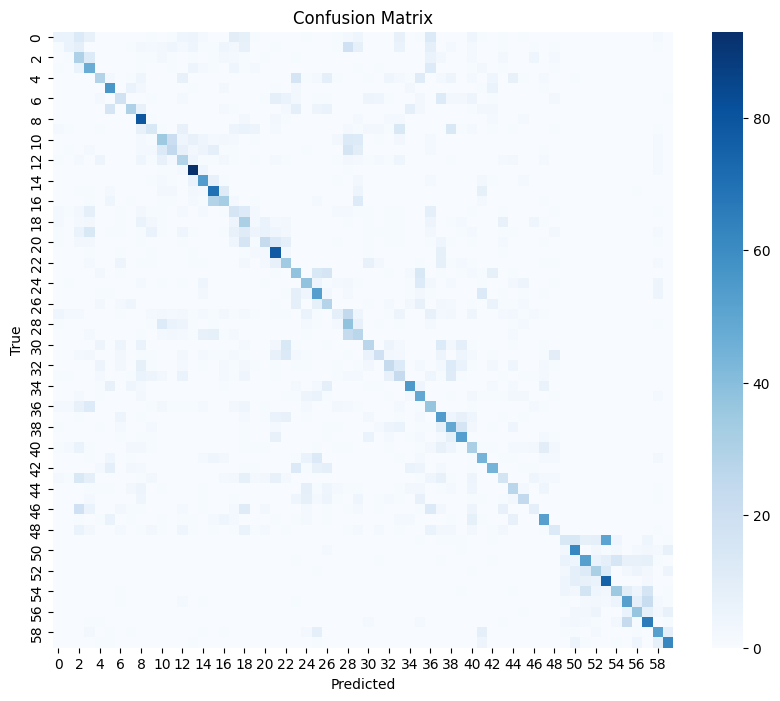

Оценка модели: 3DCNN

ОЦЕНКА МОДЕЛИ
Модель: 3dcnn
Лучшая точность при обучении: 71.61%
Параметры обучения:
  - Target frames: 150
  - Learning rate: 0.001
  - Batch size: 32

МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
   Accuracy:  85.78%
   Precision: 86.37%
   Recall:    85.78%
   F1-score:  85.78%
   FPS:       624.20

АНАЛИЗ ОШИБОК:
   Всего ошибок: 809/5688 (14.2%)

   Примеры ошибок (первые 10):
   1. True: drink water                              → Pred: make a phone call/answer phone           (conf: 27.7%)
   2. True: touch head (headache)                    → Pred: sneeze/cough                             (conf: 33.7%)
   3. True: writing                                  → Pred: typing on a keyboard                     (conf: 31.3%)
   4. True: take off a shoe                          → Pred: pickup                                   (conf: 46.4%)
   5. True: handshaking                              → Pred: drop                                     (conf: 22.4%)
   6. True: reading          

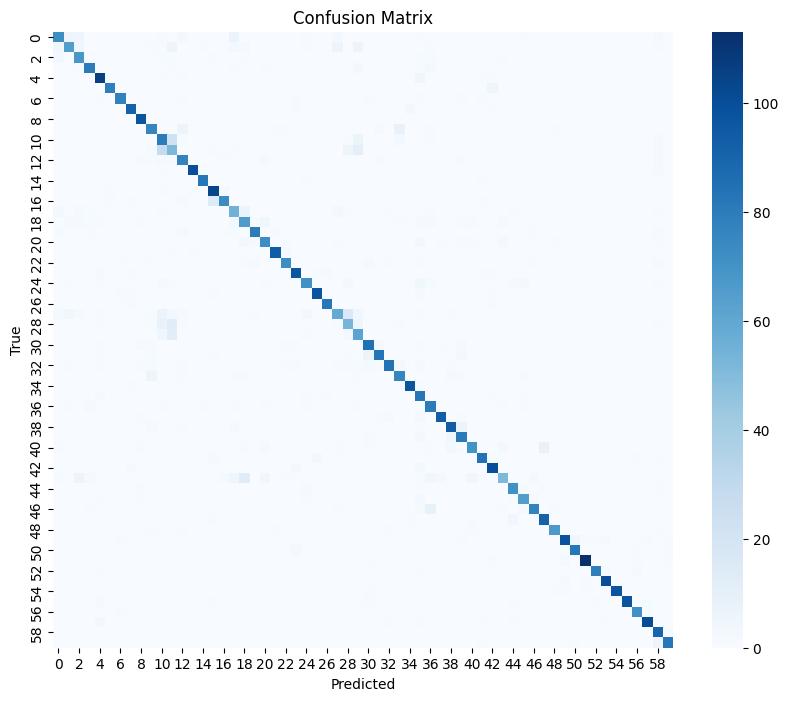

Оценка модели: STGCN

ОЦЕНКА МОДЕЛИ
Модель: stgcn
Лучшая точность при обучении: 24.12%
Параметры обучения:
  - Target frames: 150
  - Learning rate: 0.001
  - Batch size: 32

МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
   Accuracy:  23.72%
   Precision: 31.35%
   Recall:    23.72%
   F1-score:  20.89%
   FPS:       75.50

АНАЛИЗ ОШИБОК:
   Всего ошибок: 4339/5688 (76.3%)

   Примеры ошибок (первые 10):
   1. True: put on a hat/cap                         → Pred: eat meal/snack                           (conf: 12.5%)
   2. True: hopping (one foot jumping)               → Pred: shake head                               (conf: 11.3%)
   3. True: touch head (headache)                    → Pred: brushing teeth                           (conf: 14.2%)
   4. True: check time (from watch)                  → Pred: put the palms together                   (conf: 42.0%)
   5. True: wear a shoe                              → Pred: tear up paper                            (conf: 16.4%)
   6. True: staggering       

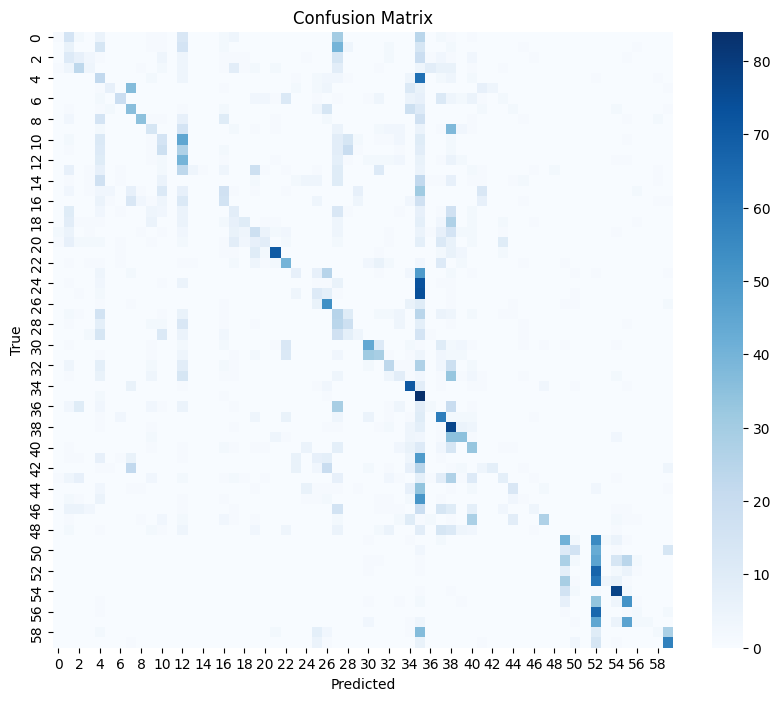

Оценка модели: TRANSFORMER

ОЦЕНКА МОДЕЛИ
Модель: transformer
Лучшая точность при обучении: 1.67%
Параметры обучения:
  - Target frames: 150
  - Learning rate: 0.0005
  - Batch size: 32

МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ:
   Accuracy:  1.71%
   Precision: 0.03%
   Recall:    1.71%
   F1-score:  0.06%
   FPS:       194.39

АНАЛИЗ ОШИБОК:
   Всего ошибок: 5591/5688 (98.3%)

   Примеры ошибок (первые 10):
   1. True: put on a hat/cap                         → Pred: standing up (from sitting position)      (conf: 1.7%)
   2. True: giving something to other person         → Pred: standing up (from sitting position)      (conf: 1.7%)
   3. True: hopping (one foot jumping)               → Pred: standing up (from sitting position)      (conf: 1.7%)
   4. True: touch head (headache)                    → Pred: standing up (from sitting position)      (conf: 1.7%)
   5. True: check time (from watch)                  → Pred: standing up (from sitting position)      (conf: 1.7%)
   6. True: wear a shoe  

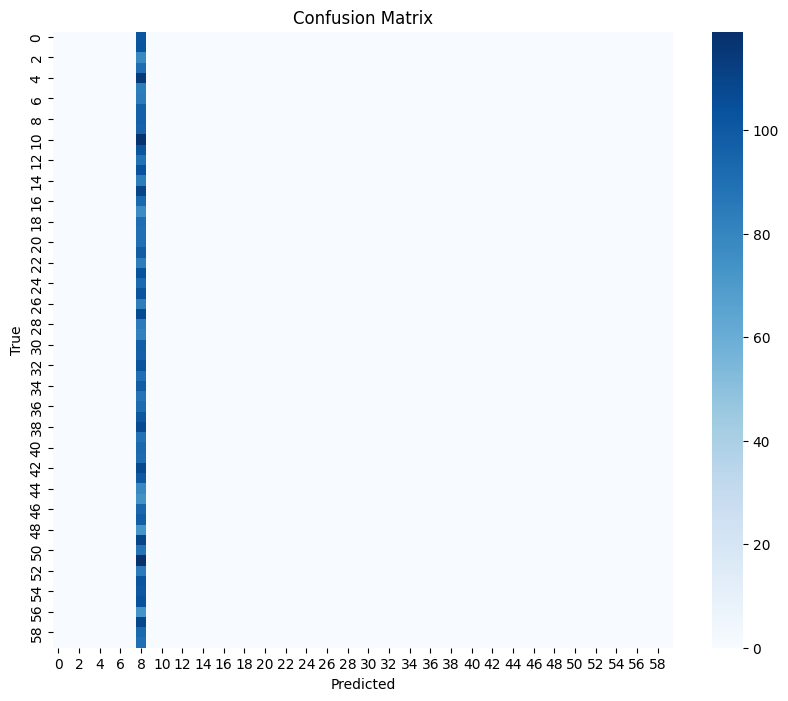

Сводное сравнение всех моделей
             Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)      FPS
MLP                 39.72          39.07       39.72         37.88  1624.23
3DCNN               85.78          86.37       85.78         85.78   624.20
STGCN               23.72          31.35       23.72         20.89    75.50
TRANSFORMER          1.71           0.03        1.71          0.06   194.39
Лучшая модель по точности: 3DCNN
   Accuracy: 85.78%
Самая быстрая модель: MLP
   FPS: 1624.23
Сравнение сохранено: results/models_comparison.csv


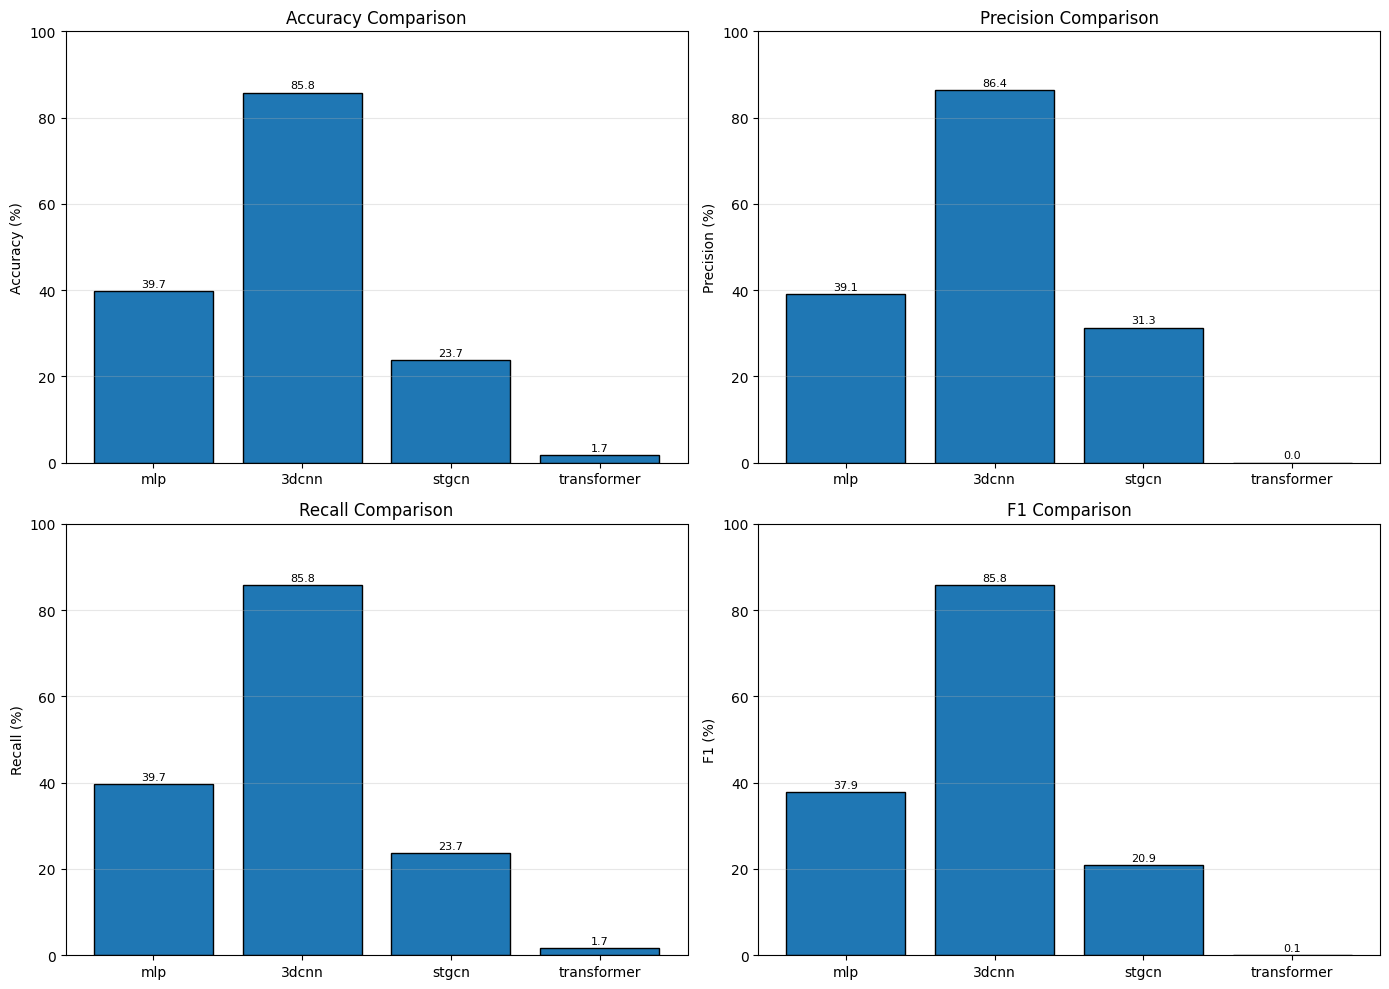


Путь к видео для демонстрации (оставьте пустым чтобы пропустить):  /home/kate/Documents/HakatonMarch2026/1.mp4



ДЕМОСТРАЦИЯ...

ДЕМОНСТРАЦИЯ НА ВИДЕО
Загрузка YOLOv8-pose модели...
YOLOv8-pose загружена
Модель: 3dcnn
Детектор: YOLOv8-pose
Максимум людей в кадре: 4

Видео: /home/kate/Documents/HakatonMarch2026/1.mp4
Разрешение: 640x360
Всего кадров: 62014
Длительность: 2586.5 сек
Размер буфера: 150 кадров
Выходное видео: results/demo_output.mp4

Обработка видео... (нажмите Q для остановки)
Прогресс: 0.0% | Кадр: 0/62014 | ETA: 728.7мин
Прогресс: 0.2% | Кадр: 100/62014 | ETA: 11.4мин
Прогресс: 0.3% | Кадр: 200/62014 | ETA: 7.7мин
Кадр 298: writing (unknown) (4.7%) | Людей: 4 | ID: 11
Прогресс: 0.5% | Кадр: 300/62014 | ETA: 9.2мин
Кадр 328: writing (unknown) (5.6%) | Людей: 4 | ID: 11
Кадр 358: walking (individual) (5.6%) | Людей: 3 | ID: 58
Кадр 388: walking (individual) (4.5%) | Людей: 2 | ID: 58
Прогресс: 0.6% | Кадр: 400/62014 | ETA: 9.8мин
Кадр 418: typing on a keyboard (unknown) (4.4%) | Людей: 2 | ID: 29
Кадр 448: typing on a keyboard (unknown) (4.6%) | Людей: 1 | ID: 29
Кадр 478: typing on

I0000 00:00:1774446735.670268   60640 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1774446735.714433   94551 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.126.09), renderer: NVIDIA GeForce RTX 5070/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


   Детекция: 24.97 мс
   Инференс: 1.99 мс
   FPS: 502.8
Бенчмарк модели: 3DCNN
MediaPipe версия: 0.10.9


I0000 00:00:1774446774.624353   60640 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1774446774.659141   94637 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.126.09), renderer: NVIDIA GeForce RTX 5070/PCIe/SSE2


   Детекция: 24.75 мс
   Инференс: 2.79 мс
   FPS: 358.8
Бенчмарк модели: STGCN
MediaPipe версия: 0.10.9


I0000 00:00:1774446814.296836   60640 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1774446814.330597   94711 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.126.09), renderer: NVIDIA GeForce RTX 5070/PCIe/SSE2


   Детекция: 24.95 мс
   Инференс: 16.35 мс
   FPS: 61.2
Бенчмарк модели: TRANSFORMER
MediaPipe версия: 0.10.9


I0000 00:00:1774446871.708841   60640 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1774446871.741858   94767 gl_context.cc:344] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.126.09), renderer: NVIDIA GeForce RTX 5070/PCIe/SSE2


   Детекция: 24.66 мс
   Инференс: 12.23 мс
   FPS: 81.8
Сравнение производительности
             Detection (ms)  Inference (ms)  Total (ms)     FPS
mlp                   24.97            1.99       26.96  502.83
3dcnn                 24.75            2.79       27.54  358.83
stgcn                 24.95           16.35       41.30   61.18
transformer           24.66           12.23       36.88   81.80
Результаты сохранены: results/benchmark_results.csv

РАБОТА ЗАВЕРШЕНА!


In [ ]:
def main():
    """
    Главная функция для запуска всех режимов работы системы
    """
    config = Config()

    print("\n" + "="*70)
    print("СИСТЕМА РАСПОЗНАВАНИЯ ДЕЙСТВИЙ ПО СКЕЛЕТНЫМ ДАННЫМ")
    print("Разработано для онлайн-кинотеатра «КИОН»")
    print("="*70)
    print(f"\nУстройство: {config.device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # Создание директорий
    os.makedirs(config.MODELS_DIR, exist_ok=True)
    os.makedirs(config.RESULTS_DIR, exist_ok=True)
    os.makedirs(config.LOGS_DIR, exist_ok=True)

    print("\n" + "="*70)
    print("ВЫБЕРИТЕ РЕЖИМ РАБОТЫ:")
    print("="*70)
    print("  1. Обучить одну модель")
    print("  2. Обучить все модели (MLP, 3DCNN, ST-GCN, Transformer)")
    print("  3. Сравнить все модели по метрикам")
    print("  4. Демонстрация на видео")
    print("  5. Бенчмарк производительности всех моделей")
    print("  6. Полный цикл (обучение → сравнение → демо → бенчмарк)")
    print("  7. Вывести информацию о моделях")
    print("  8. ПЕРЕОБУЧИТЬ ВСЕ МОДЕЛИ с оптимизированными параметрами (с проверкой существующих)")
    print("  9. ПРИНУДИТЕЛЬНО переобучить все модели (перезаписать существующие)")
    print("  0. Быстрый старт (обучить 3DCNN + демо)")
    print("="*70)

    choice = input("\nВведите номер режима (0-9): ").strip()

    if choice == '0':
        # Быстрый старт для демонстрации
        print("\nБЫСТРЫЙ СТАРТ...")
        print("\n[1/3] Обучение модели 3DCNN...")
        train_model('3dcnn', num_epochs=30)

        print("\n[2/3] Оценка модели...")
        evaluate_model('models/3dcnn_best.pth')

        print("\n[3/3] Готово!")
        print(f"Модель сохранена: {config.MODELS_DIR}/3dcnn_best.pth")
        print(f"Результаты в: {config.RESULTS_DIR}/")

    elif choice == '1':
        print("\nДоступные модели:")
        for name in MODELS.keys():
            print(f"  - {name}: {MODELS[name]['description']}")
        model_name = input("\nВведите название модели: ").strip().lower()
        if model_name in MODELS:
            epochs = input("Количество эпох (по умолчанию 150): ").strip()
            epochs = int(epochs) if epochs else 150
            train_model(model_name, num_epochs=epochs)
        else:
            print(f"Модель '{model_name}' не найдена")

    elif choice == '2':
        print("\nОБУЧЕНИЕ ВСЕХ МОДЕЛЕЙ...")
        for model_name in MODELS.keys():
            print(f"\n{'#'*70}")
            print(f"# ОБУЧЕНИЕ МОДЕЛИ: {model_name.upper()}")
            print(f"{'#'*70}")
            train_model(model_name, num_epochs=100)
        print("\nОбучение всех моделей завершено!")
        compare_all_models()

    elif choice == '3':
        compare_all_models()

    elif choice == '4':
        print("\nДоступные модели:")
        for name in MODELS.keys():
            model_path = os.path.join(config.MODELS_DIR, f'{name}_best.pth')
            status = "✅" if os.path.exists(model_path) else "❌"
            print(f"  {status} {name}: {MODELS[name]['description']}")

        model_name = input("\nВведите название модели для демонстрации: ").strip().lower()
        if model_name not in MODELS:
            print(f"Модель '{model_name}' не найдена")
            return

        model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
        if not os.path.exists(model_path):
            print(f"Модель не обучена. Сначала обучите её.")
            return

        video_path = input("Путь к видео: ").strip()
        if not video_path:
            print("Не указан путь к видео")
            return

        output_path = input("Путь для выходного видео (по умолчанию results/demo_output.mp4): ").strip()
        if not output_path:
            output_path = os.path.join(config.RESULTS_DIR, 'demo_output.mp4')

        # Запрос параметров для ускорения
        skip_frames = input("Пропуск кадров (1-10, по умолчанию 2): ").strip()
        skip_frames = int(skip_frames) if skip_frames else 2

        max_people = input("Максимум людей в кадре (1-4, по умолчанию 4): ").strip()
        max_people = int(max_people) if max_people else 4

        demo_video(model_path, video_path, output_path, skip_frames, max_people)

    elif choice == '5':
        video_path = input("Путь к видео для бенчмарка: ").strip()
        if not video_path:
            print("Не указан путь к видео")
            return
        duration = input("Длительность теста в секундах (по умолчанию 60): ").strip()
        duration = int(duration) if duration else 60
        benchmark_all_models(video_path, duration)

    elif choice == '6':
        print("\nЗАПУСК ПОЛНОГО ЦИКЛА...")

        # Обучение всех моделей
        for model_name in MODELS.keys():
            model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
            if not os.path.exists(model_path):
                print(f"\n{'#'*70}")
                print(f"# ОБУЧЕНИЕ МОДЕЛИ: {model_name.upper()}")
                print(f"{'#'*70}")
                train_model(model_name, num_epochs=100)
            else:
                print(f"\nМодель {model_name} уже обучена")

        # Сравнение
        print("\nСРАВНЕНИЕ МОДЕЛЕЙ...")
        compare_all_models()

        # Демонстрация
        video_path = input("\nПуть к видео для демонстрации (оставьте пустым чтобы пропустить): ").strip()
        if video_path:
            print("\nДЕМОСТРАЦИЯ...")
            best_model_path = os.path.join(config.MODELS_DIR, '3dcnn_best.pth')
            demo_video(best_model_path, video_path, skip_frames=2, max_people=4)

            print("\nБЕНЧМАРК...")
            benchmark_all_models(video_path)

    elif choice == '7':
        print("\n" + "="*70)
        print("ИНФОРМАЦИЯ О МОДЕЛЯХ")
        print("="*70)
        for name, info in MODELS.items():
            print(f"\n{name.upper()}")
            print(f"   Описание: {info['description']}")
            print(f"   Особенности: {', '.join(info['features'])}")
            print(f"   Параметры: {info['params']}")
            model_path = os.path.join(config.MODELS_DIR, f'{name}_best.pth')
            if os.path.exists(model_path):
                checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
                acc = checkpoint.get('accuracy', 0)
                cfg = checkpoint.get('config', {})
                print(f"   Статус: Обучена (Accuracy: {acc:.2f}%)")
                if cfg:
                    print(f"   Параметры обучения: target_frames={cfg.get('target_frames', 'N/A')}")
            else:
                print(f"   Статус: Не обучена")

    elif choice == '8':
        # Переобучение с проверкой существующих моделей
        retrain_all_models_optimized(force_retrain=False)

    elif choice == '9':
        # Принудительное переобучение всех моделей
        print("\nПРИНУДИТЕЛЬНОЕ ПЕРЕОБУЧЕНИЕ ВСЕХ МОДЕЛЕЙ")
        confirm = input("Это займёт много времени. Все существующие модели будут перезаписаны. Продолжить? (y/n): ").strip().lower()
        if confirm == 'y':
            retrain_all_models_optimized(force_retrain=True)
        else:
            print("Операция отменена")

    else:
        print("Неверный выбор")

    print("\n" + "="*70)
    print("РАБОТА ЗАВЕРШЕНА!")
    print("="*70)

# Запуск главной функции
if __name__ == "__main__":
    main()

Анализ результатов обучения и сравнения моделей

Общие условия эксперимента

- Датасет: NTU RGB+D 60 (60 классов действий)
- Размер выборки: 56,880 образцов (train: 51,192, val: 5,688, test: 5,688)
- Параметры: 150 кадров последовательности, 25 суставов скелета, до 4 человек в кадре
- Аугментация: временной сдвиг, масштабирование, шум, зеркалирование, вращение
- Обучение: 150 эпох, ранняя остановка при 30 эпохах без улучшения
- Модели: MLP, 3DCNN, ST-GCN, Transformer



Результаты моделей на тестовой выборке

| Модель      | Accuracy | Precision | Recall | F1-score | FPS |
|-------------|----------|-----------|--------|----------|--------|
| 3DCNN       | 85.78%   | 86.37%    | 85.78% | 85.78%   | 624.20 |
| MLP         | 39.72%   | 39.07%    | 39.72% | 37.88%   | 1624.23|
| ST-GCN      | 23.72%   | 31.35%    | 23.72% | 20.89%   | 75.50  |
| Transformer | 1.71%    | 0.03%     | 1.71%  | 0.06%    | 194.39 |

---

Анализ каждой модели

1. 3DCNN (Лучшая модель) – 85.78%
Почему справилась:**
- Эффективно извлекает пространственно-временные признаки через 3D свертки
- Архитектура учитывает структуру скелета через свертки по времени и суставам
- Хорошо справляется с обоими типами действий (индивидуальные и групповые)
- Оптимальный баланс между сложностью и обобщающей способностью
- Низкая ошибка: всего 14.2% ошибок на тестовой выборке

2. MLP – 39.72%
Почему не справилась лучше:
- Полносвязная сеть игнорирует пространственно-временную структуру данных
- Не учитывает связи между суставами
- Сильно переобучается при увеличении сложности
- Ограниченная способность к обобщению
- Плюсы: максимальная скорость (1624 FPS), подходит для real-time приложений с низкими требованиями к точности

3. ST-GCN – 23.72%
Почему не справилась:
- Сильное переобучение: Train Acc росла (61.93%), а Val Acc падала (17.72%)
- Графовая структура требует больше данных для качественного обучения
- Вероятно, архитектура слишком сложная для размера обучающей выборки
- Требует более тонкой настройки гиперпараметров и регуляризации
- Плюсы: хороший потенциал для больших датасетов

4. Transformer – 1.71%
Почему полностью не справилась:
- Полный коллапс обучения: практически случайное угадывание (1.71% для 60 классов)
- Трансформеры требуют значительно больше данных для обучения
- Механизм self-attention неэффективен на относительно небольших датасетах
- Сложность модели (3.2M параметров) недостаточна для извлечения паттернов из скелетных данных
- Причина: архитектура не адаптирована для скелетных последовательностей без дополнительной предобработки


Основные выводы

1. 3DCNN показала наилучший результат (85.78%) – оптимальный выбор для задачи распознавания действий по скелетным данным. Учитывает как пространственную структуру, так и временную динамику.

2. MLP – компромисс между скоростью и точностью (39.72% при 1624 FPS). Подходит для real-time приложений, где допустима более низкая точность.

3. ST-GCN и Transformer не справились:
   - ST-GCN: переобучение из-за сложной графовой структуры
   - Transformer: полный коллапс из-за недостаточного объема данных и неподходящей архитектуры

4. Ключевые факторы успеха:
   - Учет пространственно-временной структуры данных
   - Соответствие сложности модели размеру выборки
   - Правильный выбор аугментации и регуляризации

5. Рекомендация: для практического использования рекомендуется 3DCNN как оптимальный баланс точности (85.78%) и производительности (624 FPS).

In [ ]:
Веса моделей

In [ ]:
https://drive.google.com/drive/folders/14X8Qd1jUvp4aKQTTfV9-HZyBbEjIzQpj?usp=sharing